# Joining data

In [1]:
from pathlib import Path
print(Path.cwd())
# r: raw string
# f: formatted string

import pandas as pd

file_path = Path(r'C:\Users\xiang\Documents\backup_T580\Videos\Videos\Dropbox\p_jobinterview\coding\datacamp')
df1 = pd.read_csv(file_path/'data'/'Chicago_census.csv') # it is already in the directory
print(df1.head(2))

df2 = pd.read_csv(file_path/'data'/'Chicago_wards.csv') # it is already in the directory
print(df2.head(2))

c:\Users\xiang\Documents\backup_T580\Videos\Videos\Dropbox\p_jobinterview\coding\datacamp
   Unnamed: 0  ward  pop_2000  pop_2010 change                      address  \
0           0   NaN     52951     56149     6%  2765 WEST SAINT MARY STREET   
1           1   2.0     54361     55805     3%     WM WASTE MANAGEMENT 1500   

     zip  
0  60647  
1  60622  
   Unnamed: 0  ward            alderman                     address    zip
0           0    61  Proco "Joe" Moreno   2058 NORTH WESTERN AVENUE  60647
1           1     2       Brian Hopkins  1400 NORTH  ASHLAND AVENUE  60622


## inner join

In [2]:
# inner join and rename columns in both tables
df_inner=df1.merge(df2, on='ward', suffixes=('_census', '_ward'))
print(df_inner.head(2))


   Unnamed: 0_census  ward  pop_2000  pop_2010 change  \
0                  1   2.0     54361     55805     3%   
1                  2   3.0     40385     53039    31%   

             address_census  zip_census  Unnamed: 0_ward       alderman  \
0  WM WASTE MANAGEMENT 1500       60622                1  Brian Hopkins   
1       17 EAST 38TH STREET       60653                2     Pat Dowell   

                 address_ward  zip_ward  
0  1400 NORTH  ASHLAND AVENUE     60622  
1     5046 SOUTH STATE STREET     60609  


## many to one

In [3]:
# many merged to one
bizonwers = pd.read_csv(file_path/'data'/'licenses.csv')
print(bizonwers.head(2))
print(bizonwers.shape)

df3=df2.merge(bizonwers, on='ward')
biz_count=df3.groupby('ward').agg({'aid':'count'}) # find aid variable and count it
    # same way 
    # biz_count=df3.groupby('ward')['aid'].count()
print(biz_count.sort_values(by=['ward','aid']).head(5))


   Unnamed: 0  account  ward  aid              business              address  \
0           0   307071     3  743  REGGIE'S BAR & GRILL      2105 S STATE ST   
1           1       10    10  829            HONEYBEERS  13200 S HOUSTON AVE   

       zip  
0  60616.0  
1  60633.0  
(10000, 7)
      aid
ward     
2     162
3      90
4     101
5      49
6      62


## left, right, outer, self join

In [4]:
# left, right, outer join and on different id
# df0.merge(df1, on=['var1', 'var2'], how='left')

# # df0.merge(df1, 
#   how='left', 
#   left_on='var1', 
#   right_on='var2') # this allow self join

# merging based on indices
# # df0.merge(df1, 
#   how='left',
#   left_on='var1', left_index=True, 
#   right_on='var2', right_index=True) # this allow self join

## semi, anti join

In [5]:
# semi join: 
# finding rows on the left table based on the rows in the right able
df1 = pd.read_csv(file_path/'data'/'movies.csv') # it is already in the directory
print(df1.head(2), df1.shape)

df2 = pd.read_csv(file_path/'data'/'movie_to_genres.csv') # it is already in the directory
print(df2.head(2),df2.shape )

df3=df1.merge(df2, right_on='movie_id', left_on='id', indicator=True) # indicator here similar to stata telling merged or not

# using isin to filter data
df3['id'].isin(df2['movie_id']).head(5)


   Unnamed: 0     id                 title  popularity release_date
0           0    257          Oliver Twist   20.415572   2005-09-23
1           1  14290  Better Luck Tomorrow    3.877036   2002-01-12 (4803, 5)
   Unnamed: 0  movie_id   genre
0           0         5   Crime
1           1         5  Comedy (12160, 3)


0    True
1    True
2    True
3    True
4    True
Name: id, dtype: bool

## vertical concat

```pd.concat() ``` includes all columns in all columns (by default). ```pd.concat(..., join='inner') ```includes common columns, and  ```.concet(..., sort=True)``` sorts the column names.

* index value is retained
```
pd.concat([df1, df2])
```
* reset index
```
pd.concat([df1, df2], ignore_index=True)
```
* create a multi-level index with the outer index for the two chunks of datasets
```
pd.concat([df1, df2], ignore_index=False, keys=['data1', 'data2'])
```




## validate integrity

```pd.concat(..., validate_integrity=True) ``` validates if there are duplicates of index values.

```df_left.merge(df_right,on=..., validate='one-to-many')``` checks the duplicates of rows for **df_left** being 'one' and **df_right** being 'many'.

## merge_ordered

![merge_ordered](merge_merge_ordered_comparison.png "")


```
pd.merge_ordered(left, right, on=<...>, left_by=<...>, right_by=<...>, fill_method=<...>, suffixes=('_x', '_y'), how='outer')
```

Note that ```on=['country','date']``` is different from ```on=['date', 'country']``` because they differ how NA is filled.



In [ ]:
df1 = pd.DataFrame({
    'date': pd.to_datetime(['2020-01-01','2020-01-03','2020-01-06']),
    'A': [1, 3, 6]
})

df2 = pd.DataFrame({
    'date': pd.to_datetime(['2020-01-02','2020-01-03','2020-01-05']),
    'B': [10, 30, 50]
})

pd.merge_ordered(df1, df2, on='date')

,date,A,B
0,2020-01-01,1.0,NaN
1,2020-01-02,NaN,10.0
2,2020-01-03,3.0,30.0
3,2020-01-05,NaN,50.0
4,2020-01-06,6.0,NaN


In [7]:
# filling values downwards (forward fill)
pd.merge_ordered(df1, df2, on='date', fill_method='ffill')

,date,A,B
0,2020-01-01,1,NaN
1,2020-01-02,1,10.0
2,2020-01-03,3,30.0
3,2020-01-05,3,50.0
4,2020-01-06,6,50.0


## pd.merge_asof()
Finding the closest matched data from the right table.
    Direction (```direction``` parameter):
* ```backward``` (default): Selects the last row in the right DataFrame whose key is less than or equal to the left key.
* ```forward```: Selects the first row in the right DataFrame whose key is greater than or equal to the left key.
* ```nearest```: Selects the row in the right DataFrame with the closest key.

Note: for time series, ```df['price_diff'] = df['price'].diff()``` calculate the first difference.

Note on using case_when()

C:\Users\xiang\AppData\Local\Temp\ipykernel_30172\7694089.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range('2019-01-01', periods=24, freq='M')


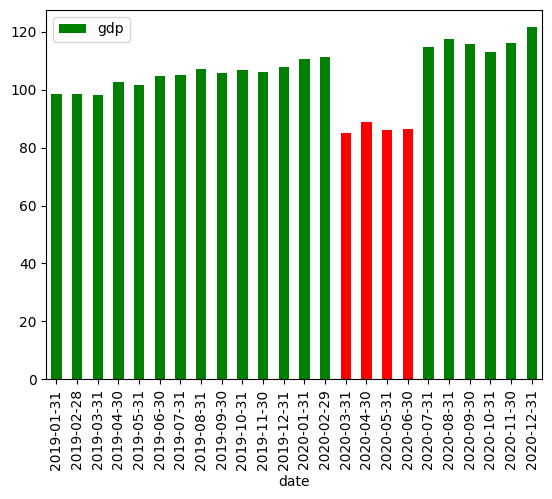

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

dates = pd.date_range('2019-01-01', periods=24, freq='M')
# create a small GDP drop for a recession period (Mar–Jun 2020)
gdp = [100 + i*0.8 + ( -25 if (d.year==2020 and d.month in (3,4,5,6)) else 0) + np.random.randn()*1.5
       for i, d in enumerate(dates)]
econ_status = ['recession' if (d.year==2020 and d.month in (3,4,5,6)) else 'growth' for d in dates]

gdp_recession = pd.DataFrame({'date': dates, 'gdp': gdp, 'econ_status': econ_status})
gdp_recession.head()


# Create a list based on the row value of gdp_recession['econ_status']
is_recession = ['r' if s=='recession' else 'g' for s in gdp_recession['econ_status']]

# refomat date time
gdp_recession['date']=pd.to_datetime(gdp_recession['date']).dt.date

# Plot a bar chart of gdp_recession
gdp_recession.plot(kind='bar', y='gdp', x='date', color=is_recession, rot=90)
plt.show()



## subseting data with df.query()

```df.query('<condition>')``` is similar to ```WHERE <condition>``` clause in SQL.

# Exploratory data analysis

## Knowing data

In [18]:
from pathlib import Path
import pandas as pd
import numpy as np
file=Path.cwd()
unemployment=pd.read_csv(file/'data'/'clean_unemployment.csv')
unemployment.head()

,country_code,country_name,continent,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,AFG,Afghanistan,Asia,11.35,11.05,11.34,11.19,11.14,11.13,11.16,11.18,11.15,11.22,11.71,13.28
1,AGO,Angola,Africa,9.43,7.36,7.35,7.37,7.37,7.39,7.41,7.41,7.42,7.42,8.33,8.53
2,ALB,Albania,Europe,14.09,13.48,13.38,15.87,18.05,17.19,15.42,13.62,12.30,11.47,13.33,11.82
3,ARE,United Arab Emirates,Asia,2.48,2.30,2.18,2.04,1.91,1.77,1.64,2.46,2.35,2.23,3.19,3.36
4,ARG,Argentina,South America,7.71,7.18,7.22,7.10,7.27,7.52,8.11,8.35,9.22,9.84,11.46,10.90


In [19]:
unemployment.info() # to check missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  182 non-null    object 
 1   country_name  182 non-null    object 
 2   continent     178 non-null    object 
 3   2010          182 non-null    float64
 4   2011          182 non-null    float64
 5   2012          182 non-null    float64
 6   2013          182 non-null    float64
 7   2014          182 non-null    float64
 8   2015          182 non-null    float64
 9   2016          182 non-null    float64
 10  2017          182 non-null    float64
 11  2018          182 non-null    float64
 12  2019          182 non-null    float64
 13  2020          182 non-null    float64
 14  2021          182 non-null    float64
dtypes: float64(12), object(3)
memory usage: 21.5+ KB


In [ ]:
unemployment['continent']=unemployment['continent'].replace('Null', np.nan)
# count each category column
unemployment.value_counts('continent') # why only 177 values
# importing csv recognizes NaN and NA as missing values

continent
Africa           53
Asia             47
Europe           39
North America    18
South America    12
Oceania           8
Name: count, dtype: int64

In [21]:
unemployment['continent'].describe()

count        177
unique         6
top       Africa
freq          53
Name: continent, dtype: object

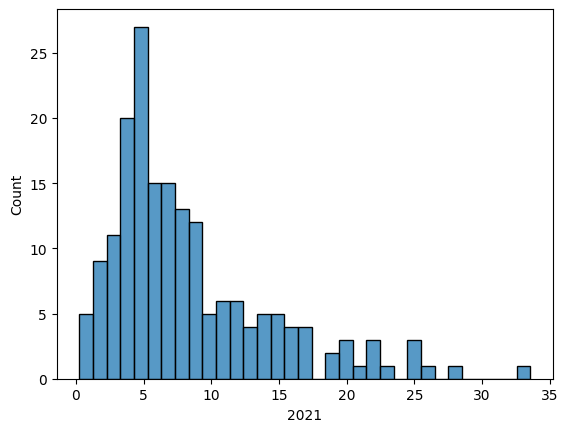

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# distribution of unemployment in all countries
sns.histplot(data=unemployment, x='2021', binwidth=1)
plt.show()

## data validation

In [29]:
# checking data types
unemployment['continent']=unemployment['continent'].astype(str)
unemployment.dtypes.head(2)

country_code    object
country_name    object
dtype: object

In [28]:
# checking set values `isin()`
not_oceania = ~unemployment["continent"].isin(["Oceania"])
unemployment[not_oceania].head(2)

,country_code,country_name,continent,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,AFG,Afghanistan,Asia,11.35,11.05,11.34,11.19,11.14,11.13,11.16,11.18,11.15,11.22,11.71,13.28
1,AGO,Angola,Africa,9.43,7.36,7.35,7.37,7.37,7.39,7.41,7.41,7.42,7.42,8.33,8.53


0.26 33.56


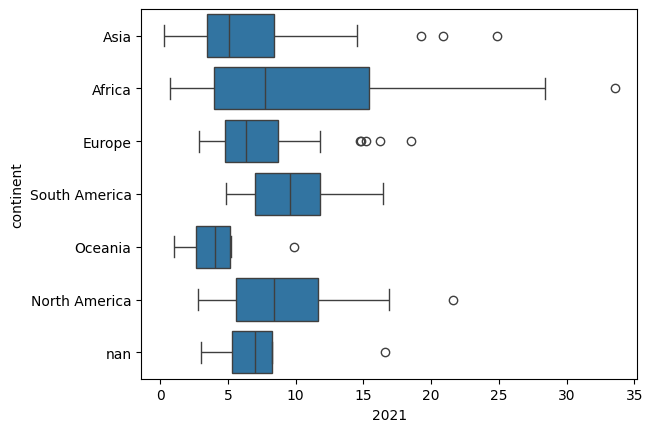

In [30]:
# checking ranges using boxplot
print(unemployment['2021'].min(), unemployment['2021'].max())

sns.boxplot(data=unemployment, x='2021', y='continent')
plt.show()

## summarization

- `.groupby()`: working with category variables
- `.sum()`, `.count()`, `.mean()` etc: aggregating functions
- `.agg()`: to apply multiple aggregating function
    - use dict:  `{'column_name': ['mean', 'median'], ...}`
    - use tuple: `new_var_name=('column_name', 'mean')`

> customized function for pandas

In [33]:
unemployment[['country_name',"continent", "2019", "2020"]].groupby(['country_name','continent']).agg(['mean', 'std']).head(2)

2019       2020    
                         mean std   mean std
country_name continent                      
Afghanistan  Asia       11.22 NaN  11.71 NaN
Albania      Europe     11.47 NaN  13.33 NaN

In [35]:
print(unemployment[["continent", "2019", "2020"]].groupby("continent").agg(['mean', 'std']))
continent_summary = unemployment.groupby("continent").agg(
    # Create the mean_rate_2021 column
    mean_rate_2021=('2021', 'mean'),
    # Create the std_rate_2021 column
    std_rate_2021=('2021','std')
)
print(continent_summary)

                   2019                 2020          
                   mean       std       mean       std
continent                                             
Africa         9.264340  7.455293  10.307736  7.928166
Asia           5.949149  5.254008   7.012340  5.699609
Europe         6.764359  4.124734   7.470513  4.071218
North America  7.095000  4.770490   9.297778  4.963045
Oceania        3.773750  2.369068   4.273750  2.617490
South America  7.719167  3.379845  10.275000  3.411263
nan            6.680000  5.246275   8.104000  5.182584
               mean_rate_2021  std_rate_2021
continent                                   
Africa              10.473585       8.131636
Asia                 6.906170       5.414745
Europe               7.414872       3.947825
North America        9.155000       5.076482
Oceania              4.280000       2.671522
South America        9.924167       3.611624
nan                  8.030000       5.163240


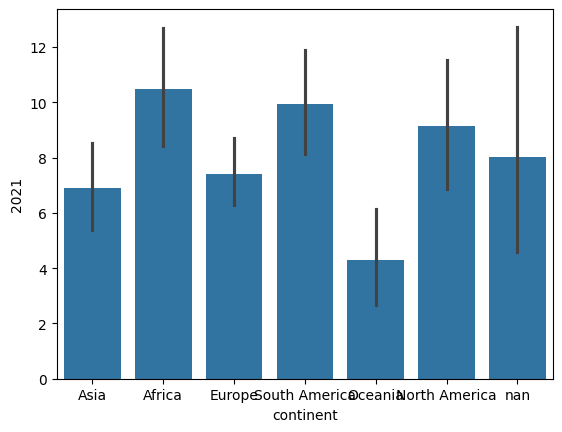

In [36]:
sns.barplot(data=unemployment,x='continent',y='2021')
plt.show()

## missing data

Handling them:
- dropping
- imputing by summary stats
- imputing by group stats

In [39]:
from pathlib import Path
file=Path.cwd()
planes=pd.read_csv(file/'data'/'planes.csv')
planes.info()
print(len(planes))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10660 entries, 0 to 10659
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          10233 non-null  object 
 1   Date_of_Journey  10338 non-null  object 
 2   Source           10473 non-null  object 
 3   Destination      10313 non-null  object 
 4   Route            10404 non-null  object 
 5   Dep_Time         10400 non-null  object 
 6   Arrival_Time     10466 non-null  object 
 7   Duration         10446 non-null  object 
 8   Total_Stops      10448 non-null  object 
 9   Additional_Info  10071 non-null  object 
 10  Price            10044 non-null  float64
dtypes: float64(1), object(10)
memory usage: 916.2+ KB
10660


In [49]:
planes['Source'].isna().sum()
planes.isna().sum()

Airline              0
Date_of_Journey      0
Source               0
Destination          0
Route                0
Dep_Time             0
Arrival_Time         0
Duration             0
Total_Stops          0
Additional_Info    300
Price              368
dtype: int64

In [46]:
# return the column indices
planes.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [55]:
# Filter the DataFrame for object columns
non_numeric = planes.select_dtypes("object")
# Loop through columns
for i in non_numeric.columns:
  # Print the number of unique values
  print(f"Number of unique values in {i} column: ", non_numeric[i].nunique())

Number of unique values in Airline column:  8
Number of unique values in Date_of_Journey column:  44
Number of unique values in Source column:  5
Number of unique values in Destination column:  6
Number of unique values in Route column:  122
Number of unique values in Dep_Time column:  218
Number of unique values in Arrival_Time column:  1220
Number of unique values in Duration column:  362
Number of unique values in Total_Stops column:  5


### dropping rows with NaN

In [47]:
# Find the five percent threshold
threshold = len(planes) * 0.05

# Create a filter
cols_to_drop = planes.columns[planes.isna().sum() <= threshold]

# Drop missing values for columns below the threshold
planes.dropna(subset=cols_to_drop, inplace=True)

print(planes.isna().sum())

Airline              0
Date_of_Journey      0
Source               0
Destination          0
Route                0
Dep_Time             0
Arrival_Time         0
Duration             0
Total_Stops          0
Additional_Info    300
Price              368
dtype: int64


### dropping columns

In [52]:
# Check the values of the Additional_Info column 
print(planes["Additional_Info"].value_counts())

# no useful info so I can drop
planes.drop(columns=["Additional_Info"], inplace=True)

# or planes2=planes.drop(columns=['Additional_Info'])

Additional_Info
No info                         6399
In-flight meal not included     1525
No check-in baggage included     258
1 Long layover                    14
Change airports                    7
No Info                            2
Business class                     1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64


### imputing Nan by groups

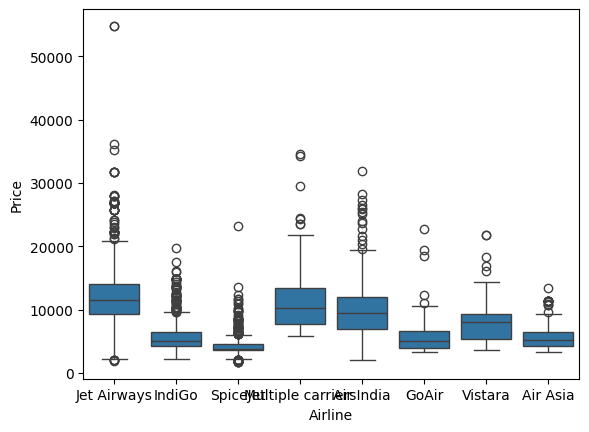

In [53]:
# Create a box plot of Price by Airline
sns.boxplot(data=planes, x='Airline',y='Price', )
plt.show()

# impute using group stats
# Calculate median plane ticket prices by Airline
airline_prices = planes.groupby("Airline")["Price"].median()

prices_dict = airline_prices.to_dict()

# Map the dictionary to missing values of Price by Airline
planes["Price"] = planes["Price"].fillna(planes["Airline"].map(prices_dict))

# rename the price
planes.rename(columns={'Price':'cleaned_price'}, inplace=True)

> `.fillna()` aligns by index labels (row labels). In this case both Series share the same index, so it’s effectively row-by-row.

> `.rename(columns={'old_name':'new_name'},inplace=True)` to change column label

## create categories

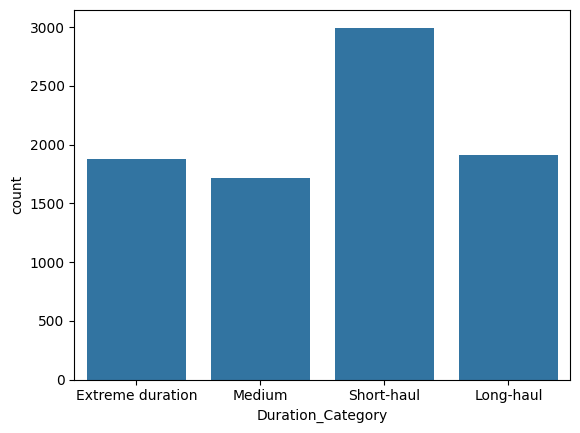

In [57]:
# 3 cases and conditions
short_flights = "^0h|^1h|^2h|^3h|^4h"
medium_flights = "^5h|^6h|^7h|^8h|^9h"
long_flights = "^10h|^11h|^12h|^13h|^14h|^15h|^16h"

conditions = [
    (planes["Duration"].str.contains(short_flights)),
    (planes["Duration"].str.contains(medium_flights)),
    (planes["Duration"].str.contains(long_flights))
]

# categories
categories = ["Short-haul", "Medium", "Long-haul"]

# case_when python way
planes["Duration_Category"] = np.select(conditions, 
                                        categories,
                                        default="Extreme duration")

# Plot the counts of each category
sns.countplot(data=planes, x="Duration_Category")
plt.show()

> `^9h`: start with 9h but `9h`: contains 9h -> 9h or 19h or 29h

## create summary stats column

using `.transform()`

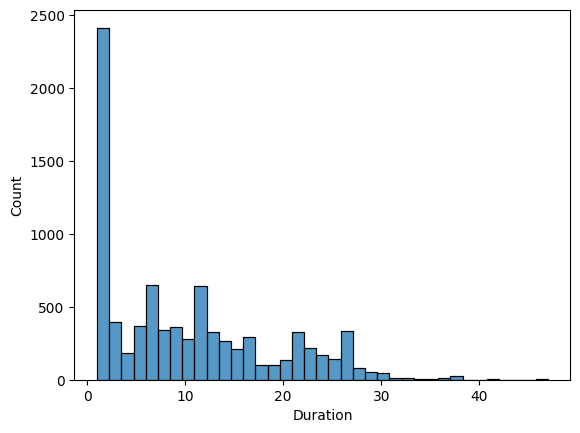

In [64]:
# Remove the string character
planes["Duration"] = planes["Duration"].str.replace("h", "")
planes["Duration"] = planes["Duration"].str.replace(r'\s.*', '', regex=True)
# Convert to float data type
planes.loc[planes["Duration"]=='5m', "Duration"]=np.nan

planes["Duration"] = planes["Duration"].astype(float)

# Plot a histogram
sns.histplot(data=planes, x='Duration')
plt.show()

> alternative using iloc for numpy array without index
```
mask = (planes["Duration"] == "5m").to_numpy()
col = planes.columns.get_loc("Duration")   # or just put the integer col index you want
planes.iloc[mask, col] = np.nan
```

In [66]:
planes["airline_median_duration"] = planes.groupby("Airline")["Duration"].transform(lambda x: x.median())

print(planes[["Airline","airline_median_duration"]].value_counts())

Airline            airline_median_duration
Jet Airways        13.0                       3082
IndiGo             2.0                        1632
Air India          15.0                       1399
Multiple carriers  10.0                        959
SpiceJet           2.0                         653
Vistara            3.0                         376
Air Asia           2.0                         260
GoAir              2.0                         147
Name: count, dtype: int64


In [73]:
# Find the 75th and 25th percentiles
price_seventy_fifth = planes["cleaned_price"].quantile(0.75)
price_twenty_fifth = planes["cleaned_price"].quantile(0.25)

# Calculate iqr
prices_iqr = price_seventy_fifth - price_twenty_fifth

# Calculate the thresholds
upper = price_seventy_fifth + (1.5 * prices_iqr)
lower = price_twenty_fifth - (1.5 * prices_iqr)

# Subset the data
planes = planes[(planes["cleaned_price"] > lower) & (planes["cleaned_price"] < upper)]

print(planes["cleaned_price"].describe())

count     8438.000000
mean      8877.466046
std       4001.838236
min       1759.000000
25%       5224.000000
50%       8372.000000
75%      12121.000000
max      22270.000000
Name: cleaned_price, dtype: float64
